<a href="https://colab.research.google.com/github/xaitex/pattern-recognition-practice/blob/main/notebooks/PR01_%D0%91%D1%80%D1%83%D1%8F%D0%BA%D0%B0_%D0%92.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практична робота 1
## Google Colab, GitHub і перше знайомство з даними
**Дисципліна:** Розпізнавання образів і машинне навчання
**Студент:** Бруяка Віталій Віталійович
**Група:** ІН-42
**Дата виконання:** 19.09.2026

### Мета роботи
Ознайомитися із середовищем Google Colab, структурою ML-проєкту, сервісом GitHub і базовими операціями аналізу табличних даних.

## 1. Підключення бібліотек
На цьому етапі підключаються бібліотеки для роботи з таблицями, числовими масивами, графіками та наборами даних машинного навчання.

In [99]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.datasets import load_iris
from IPython.display import display

print("Версія Python:", sys.version.split()[0])
print("Версія NumPy:", np.__version__)
print("Версія pandas:", pd.__version__)
print("Версія scikit-learn:", sklearn.__version__)

Версія Python: 3.13.15
Версія NumPy: 2.1.3
Версія pandas: 2.2.3
Версія scikit-learn: 1.6.1


## 2. Підключення Google Drive
Google Drive використовується для постійного зберігання наборів даних і результатів роботи. Файли у тимчасовій пам'яті Colab можуть бути видалені після завершення сеансу.

In [100]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [101]:
PROJECT_DIR = Path("/content/drive/MyDrive/pattern-recognition-practice")
DATA_DIR = PROJECT_DIR / "data"
NOTEBOOKS_DIR = PROJECT_DIR / "notebooks"
REPORTS_DIR = PROJECT_DIR / "reports"

DATA_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOKS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Робоча папка:", PROJECT_DIR)
print("Папка даних:", DATA_DIR)
print("Папка Notebook:", NOTEBOOKS_DIR)
print("Папка звітів:", REPORTS_DIR)

Робоча папка: /content/drive/MyDrive/pattern-recognition-practice
Папка даних: /content/drive/MyDrive/pattern-recognition-practice/data
Папка Notebook: /content/drive/MyDrive/pattern-recognition-practice/notebooks
Папка звітів: /content/drive/MyDrive/pattern-recognition-practice/reports


In [102]:
for path in PROJECT_DIR.iterdir():
    print(path.name)

data
notebooks
reports


## 3. Завантаження набору даних
У роботі використовується навчальний набір Iris із бібліотеки scikit-learn. Він містить вимірювання квіток трьох видів ірису.

In [103]:
iris = load_iris(as_frame=True)
print(type(iris))
print(iris.keys())

<class 'sklearn.utils._bunch.Bunch'>
dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [104]:
print("Назви ознак: ")
for feature_name in iris.feature_names:
    print("-", feature_name)

print("\nНазви класів:")
for target_name in iris.target_names:
    print("-", target_name)

Назви ознак: 
- sepal length (cm)
- sepal width (cm)
- petal length (cm)
- petal width (cm)

Назви класів:
- setosa
- versicolor
- virginica


In [105]:
df = iris.frame.copy()
display(df.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [106]:
print(df["target"].value_counts().sort_index())

target_mapping = {
    0: "setosa",
    1: "versicolor",
    2: "virginica"
}
print(target_mapping)

df["species"] = df["target"].map(target_mapping)
df = df.drop(columns=["target"])

target
0    50
1    50
2    50
Name: count, dtype: int64
{0: 'setosa', 1: 'versicolor', 2: 'virginica'}


In [107]:
df = df.rename(
    columns={
        "sepal length (cm)": "sepal_length_cm",
        "sepal width (cm)": "sepal_width_cm",
        "petal length (cm)": "petal_length_cm",
        "petal width (cm)": "petal_width_cm"
    }
)
display(df.head())

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 4. Збереження даних у форматі CSV
Підготовлена таблиця зберігається на Google Drive, після чого повторно завантажується засобами бібліотеки pandas.

In [108]:
CSV_PATH = DATA_DIR / "iris.csv"
df.to_csv(CSV_PATH, index=False)
print("Файл збережено: ")
print(CSV_PATH)

Файл збережено: 
/content/drive/MyDrive/pattern-recognition-practice/data/iris.csv


In [109]:
if CSV_PATH.exists():
    print("Файл успішно створено.")
    print("Розмір файла: ", CSV_PATH.stat().st_size, "байт")
else:
    print("Файл не знайдено.")

Файл успішно створено.
Розмір файла:  3870 байт


## 5. Читання табличних даних
Для читання CSV-файла використовується функція `pandas.read_csv()`. Результатом є об'єкт типу DataFrame.

In [110]:
data = pd.read_csv(CSV_PATH)
print("Тип об'єкта:", type(data))

Тип об'єкта: <class 'pandas.core.frame.DataFrame'>


In [111]:
display(data.head())

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [112]:
display(data.tail())

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [113]:
print("Розмір таблиці:", data.shape)
print("Кількість об'єктів:", data.shape[0])
print("Кількість стовпців:", data.shape[1])

Розмір таблиці: (150, 5)
Кількість об'єктів: 150
Кількість стовпців: 5


In [114]:
print("Назви стовпців:")
for column in data.columns:
    print("-", column)

Назви стовпців:
- sepal_length_cm
- sepal_width_cm
- petal_length_cm
- petal_width_cm
- species


In [115]:
print(data.dtypes)

sepal_length_cm    float64
sepal_width_cm     float64
petal_length_cm    float64
petal_width_cm     float64
species             object
dtype: object


In [116]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sepal_length_cm  150 non-null    float64
 1   sepal_width_cm   150 non-null    float64
 2   petal_length_cm  150 non-null    float64
 3   petal_width_cm   150 non-null    float64
 4   species          150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [117]:
missing_values = data.isna().sum()
print("Кількість пропущених значень: ")
print(missing_values)
print("Загальна кількість пропусків:", data.isna().sum().sum())

Кількість пропущених значень: 
sepal_length_cm    0
sepal_width_cm     0
petal_length_cm    0
petal_width_cm     0
species            0
dtype: int64
Загальна кількість пропусків: 0


In [118]:
duplicate_count = data.duplicated().sum()
print("Кількість повністю однакових рядків:", duplicate_count)

Кількість повністю однакових рядків: 1


In [119]:
print("Кількість унікальних значень у кожному стовпці:")
print(data.nunique())

Кількість унікальних значень у кожному стовпці:
sepal_length_cm    35
sepal_width_cm     23
petal_length_cm    43
petal_width_cm     22
species             3
dtype: int64


In [120]:
structure_summary = pd.DataFrame(
    {
        "data_type": data.dtypes.astype(str),
        "missing_values": data.isna().sum(),
        "unique_values": data.nunique()
    }
)
display(structure_summary)

,data_type,missing_values,unique_values
sepal_length_cm,float64,0,35
sepal_width_cm,float64,0,23
petal_length_cm,float64,0,43
petal_width_cm,float64,0,22
species,object,0,3


Всі чотири вимірювальні стовпці є числовими (`float64`), а стовпець `species` є категоріальним текстовим (`object`). Пропущені значення у наборі даних відсутні. Знайдено 1 повністю однаковий рядок (дублікат). Стовпець `species` має найменшу кількість унікальних значень — 3.

In [121]:
numeric_statistics = data.describe().T
display(numeric_statistics)

,count,mean,std,min,25%,50%,75%,max
sepal_length_cm,150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal_width_cm,150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal_length_cm,150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal_width_cm,150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5


In [122]:
class_counts = data["species"].value_counts()
display(class_counts.rename("count").to_frame())

,count
species,
setosa,50
versicolor,50
virginica,50


In [123]:
class_percentages = (
    data["species"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
display(class_percentages.rename("percentage").to_frame())

,percentage
species,
setosa,33.33
versicolor,33.33
virginica,33.33


## 6. Візуалізація даних
Гістограми використовуються для первинного дослідження розподілів числових ознак.

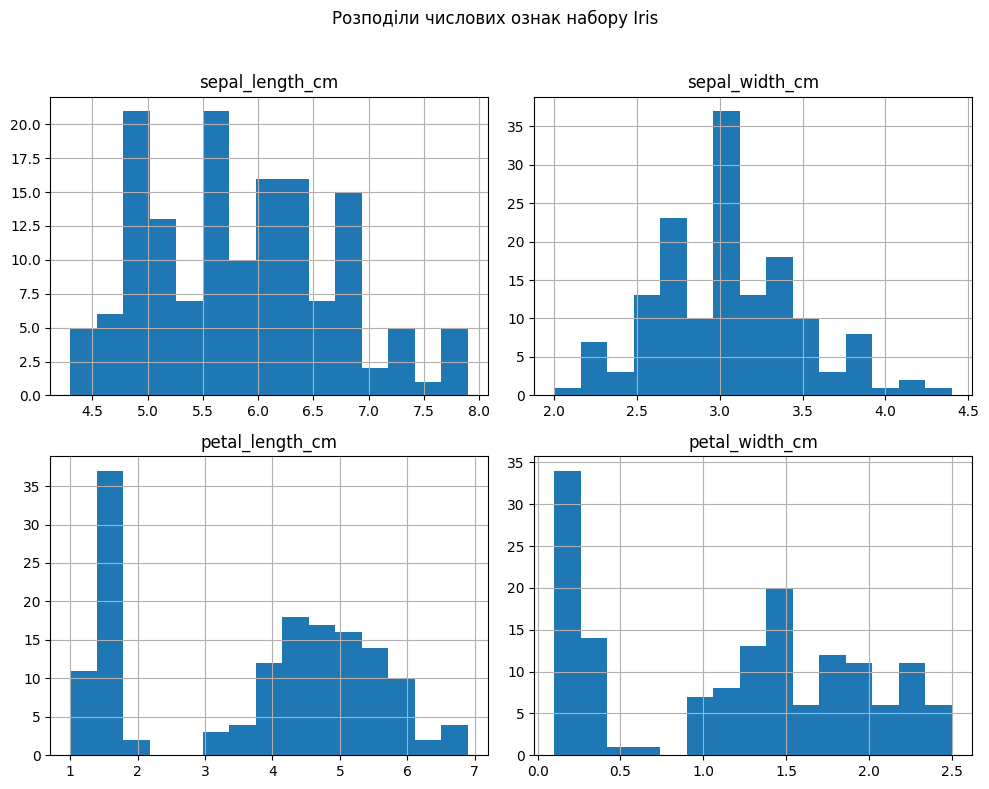

In [124]:
feature_columns = [
    "sepal_length_cm",
    "sepal_width_cm",
    "petal_length_cm",
    "petal_width_cm"
]

data[feature_columns].hist(
    bins=15,
    figsize=(10, 8)
)
plt.suptitle("Розподіли числових ознак набору Iris")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**Аналіз гістограм:**
1. Найменші значення має ознака `petal_width_cm` (ширина пелюстки).
2. Найбільший діапазон значень спостерігається у `petal_length_cm` (довжина пелюстки) та `sepal_length_cm`.
3. Розподіли мають різну форму (наприклад, `sepal_width_cm` ближче до нормального розподілу, тоді як інші мають іншу форму).
4. Кілька чітких груп значень (бімодальність) можна помітити для ознак `petal_length_cm` та `petal_width_cm`.

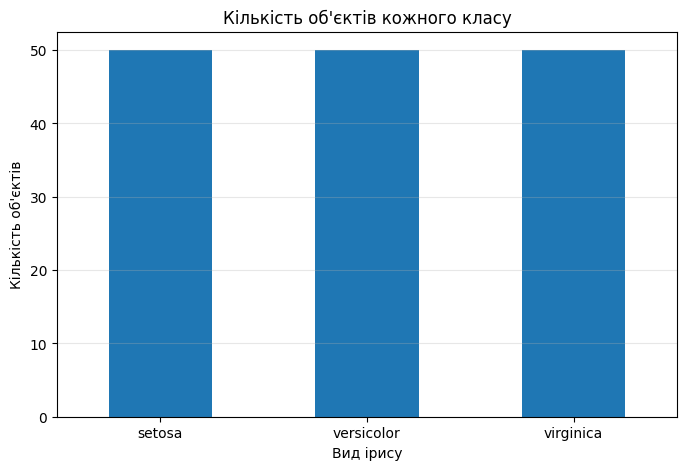

In [125]:
class_counts = data["species"].value_counts().sort_index()
class_counts.plot(
    kind="bar",
    figsize=(8, 5)
)
plt.title("Кількість об'єктів кожного класу")
plt.xlabel("Вид ірису")
plt.ylabel("Кількість об'єктів")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

**Відповідь:**
Набір даних є повністю збалансованим. Кожен із трьох класів (setosa, versicolor, virginica) містить рівно по 50 об'єктів.

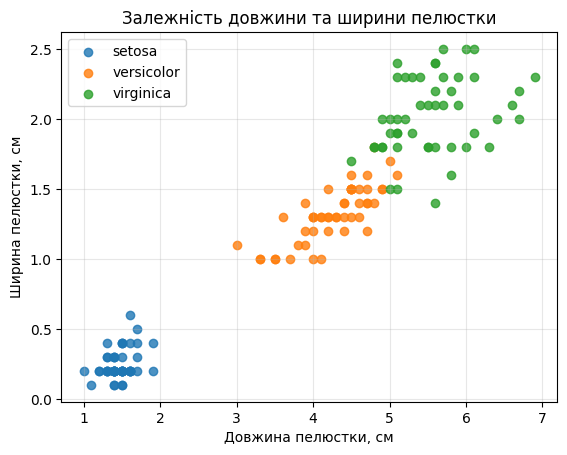

In [126]:
for species_name, group in data.groupby("species"):
    plt.scatter(
        group["petal_length_cm"],
        group["petal_width_cm"],
        label=species_name,
        alpha=0.8
    )
plt.title("Залежність довжини та ширини пелюстки")
plt.xlabel("Довжина пелюстки, см")
plt.ylabel("Ширина пелюстки, см")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Аналіз діаграми залежності:**
1. Об'єкти різних класів утворюють окремі групи.
2. Найкраще відокремлюється клас `setosa`.
3. Класи `versicolor` та `virginica` частково перекриваються між собою.
4. Так, ці ознаки можна ефективно використати для розпізнавання виду квітки.

## 7. Постановка задачі машинного навчання

### Об'єкт дослідження
Одним об'єктом є одна квітка ірису, для якої виміряно характеристики чашолистка та пелюстки.

### Ознаки
Використовуються чотири числові ознаки:
1. довжина чашолистка;
2. ширина чашолистка;
3. довжина пелюстки;
4. ширина пелюстки.

### Цільова змінна
Цільовою змінною є `species` — вид квітки ірису.

### Тип задачі
Задача належить до навчання з учителем і є задачею багатокласової класифікації.

### Формулювання задачі
Необхідно за чотирма числовими характеристиками квітки автоматично визначити, до якого з трьох видів ірису вона належить: setosa, versicolor або virginica.

In [127]:
X = data.drop(columns=["species"])
y = data["species"]
print("Розмір матриці ознак X:", X.shape)
print("Розмір цільової змінної у:", y.shape)

display(X.head())
display(y.head())

Розмір матриці ознак X: (150, 4)
Розмір цільової змінної у: (150,)


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


,species
0,setosa
1,setosa
2,setosa
3,setosa
4,setosa


In [128]:
expected_columns = {
    "sepal_length_cm",
    "sepal_width_cm",
    "petal_length_cm",
    "petal_width_cm",
    "species"
}

assert data.shape == (150, 5), f"Очікувався розмір (150, 5), отримано {data.shape}"
assert set(data.columns) == expected_columns, "Назви стовпців не відповідають очікуваним."
assert data.isna().sum().sum() == 0, "У таблиці знайдено пропущені значення."
assert data["species"].nunique() == 3, "Очікувалося три класи."
assert set(data["species"].unique()) == {"setosa", "versicolor", "virginica"}, "Назви класів не відповідають очікуваним."

print("Усі основні перевірки виконано успішно.")

Усі основні перевірки виконано успішно.


# Висновки
Під час виконання практичної роботи було створено GitHub-репозиторій для зберігання матеріалів курсу та сформовано базову структуру ML-проєкту.

У середовищі Google Colab було підключено бібліотеки NumPy, pandas, Matplotlib i scikit-learn, а також підключено Google Drive.

Для дослідження використано набір даних Iris, який містить 150 об'єктів, чотири числові ознаки та одну цільову категоріальну змінну. Об'єктом дослідження є квітка ірису, а цільовою змінною — її вид.

Під час первинного аналізу було визначено розмір таблиці, назви стовпців, типи даних, кількість пропущених значень (вони відсутні) і основні статистичні характеристики. Набір даних є повністю збалансованим (кожен з трьох класів містить по 50 об'єктів).

Також було побудовано гістограми ознак, діаграму кількості об'єктів кожного класу та діаграму залежності довжини й ширини пелюстки. Аналіз візуалізацій показав, що найкраще класи розділяють ознаки пелюстки (petal length та petal width), при цьому клас `setosa` чітко відокремлюється від інших, тоді як `versicolor` та `virginica` частково перекриваються.

Встановлено, що досліджувана задача є задачею багатокласової класифікації: за чотирма числовими ознаками необхідно визначити один із трьох видів ірису.